In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

In [71]:
df = pd.read_csv('website_traffic_dataset.csv')

In [72]:
df.shape

(365, 5)

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         365 non-null    str    
 1   Sessions     365 non-null    int64  
 2   Bounce_Rate  365 non-null    float64
 3   Pages        365 non-null    float64
 4   Visitors     365 non-null    int64  
dtypes: float64(2), int64(2), str(1)
memory usage: 14.4 KB


In [74]:
df.describe()

,Sessions,Bounce_Rate,Pages,Visitors
count,365.000000,365.000000,365.000000,365.000000
mean,708.550685,48.362548,4.362767,774.057534
std,282.014108,10.519602,1.122588,408.913173
min,201.000000,30.180000,2.520000,134.000000
25%,467.000000,39.830000,3.340000,413.000000
50%,705.000000,49.380000,4.290000,722.000000
75%,948.000000,57.710000,5.280000,1096.000000
max,1196.000000,64.990000,6.490000,1578.000000


In [75]:
df.isnull().sum()

Date           0
Sessions       0
Bounce_Rate    0
Pages          0
Visitors       0
dtype: int64

In [76]:
df.duplicated().sum()

np.int64(0)

In [77]:
df.dtypes

Date               str
Sessions         int64
Bounce_Rate    float64
Pages          float64
Visitors         int64
dtype: object

In [78]:
df['Date'] = pd.to_datetime(df['Date'])

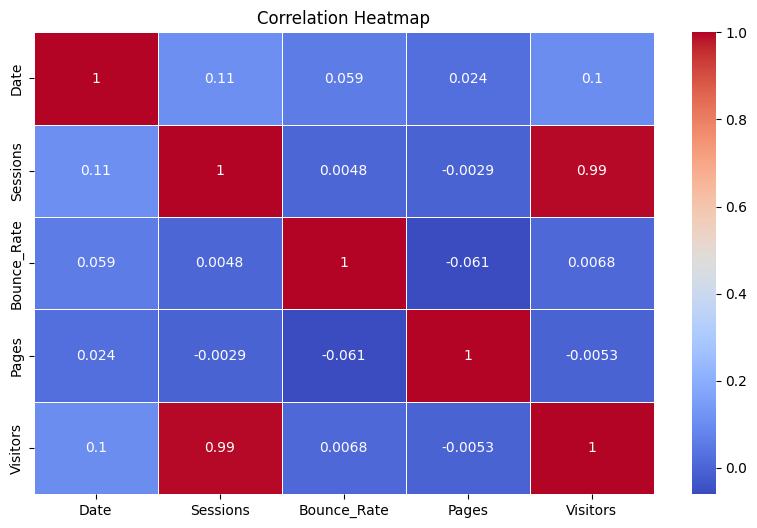

In [79]:
# Visualize the data by using heatmap to check the correlation between the features
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

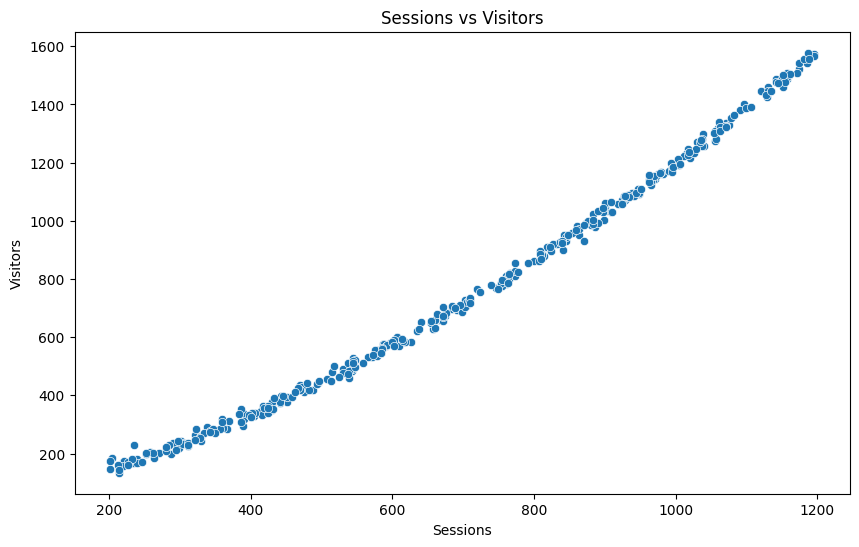

In [80]:
# Visualize the data by using scatter plot to check the relationship between the features
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sessions', y='Visitors', data=df)
plt.title('Sessions vs Visitors')
plt.xlabel('Sessions')
plt.ylabel('Visitors')
plt.show()

In [81]:
# intialising the x and y variables
x = df[['Sessions']]
y = df['Visitors']

In [82]:
# splitting the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [83]:
# linear regression model
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


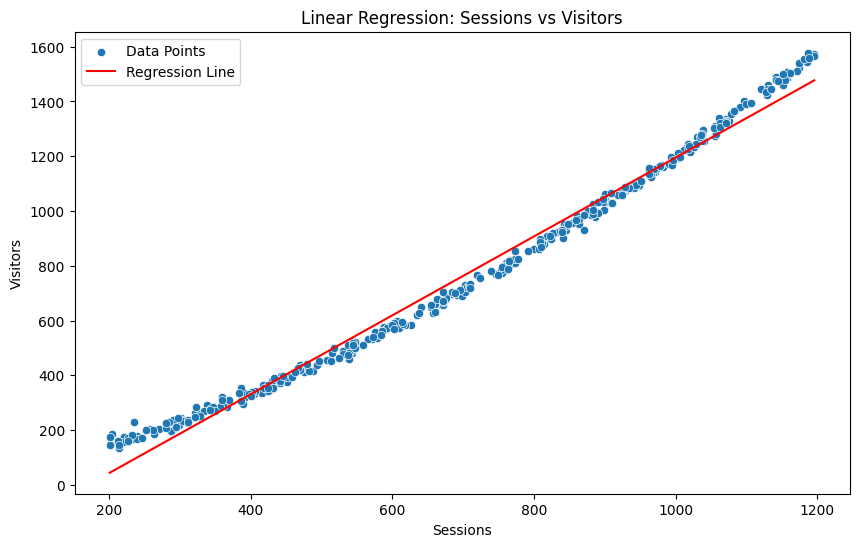

In [84]:
# visualize the linear regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sessions', y='Visitors', data=df, label='Data Points')
sns.lineplot(x=x_train['Sessions'], y=lr.predict(x_train), color='red', label='Regression Line')
plt.title('Linear Regression: Sessions vs Visitors')
plt.xlabel('Sessions')
plt.ylabel('Visitors')
plt.legend()
plt.show()

In [85]:
# polynomial regression
poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)


In [86]:
# fitting the model
lr_poly = LinearRegression()
lr_poly.fit(x_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [87]:
y_pred_poly = lr_poly.predict(x_test_poly).round(2)
y_pred_poly[:5]

array([1008.79,  466.17,  539.7 , 1139.06,  264.95])

In [88]:
# check model accuracy
mse = mean_squared_error(y_test, y_pred_poly).__round__(2)
r2 = r2_score(y_test, y_pred_poly).__round__(2)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')


Mean Squared Error: 172.51
R^2 Score: 1.0


In [89]:
# Sample prediction using Polynomial Regression

sample_poly = poly.transform([[500]])

predicted_poly = lr_poly.predict(sample_poly)

print("Polynomial Prediction for 500 sessions:", predicted_poly[0])

Polynomial Prediction for 500 sessions: 450.5333134621143


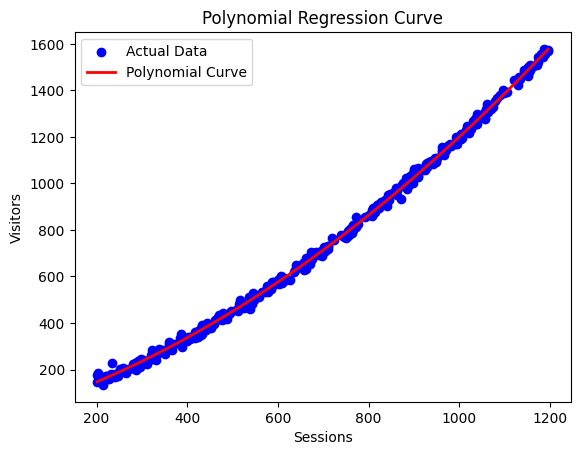

In [90]:
# Scatter plot of actual data
plt.scatter(x, y, color='blue', label='Actual Data')

# Create smooth X values
x_range = np.linspace(x.min(), x.max(), 200).reshape(-1,1)

# Convert to polynomial features
x_range_poly = poly.transform(x_range)

# Predict using polynomial model
y_range = lr_poly.predict(x_range_poly)

# Plot curve
plt.plot(x_range, y_range, color='red', linewidth=2, label='Polynomial Curve')

plt.title("Polynomial Regression Curve")
plt.xlabel("Sessions")
plt.ylabel("Visitors")
plt.legend()

plt.show()